# Prédiction des maladies cardiaques par régression logistique 🫀

**Ensemble de données : UCI Heart Disease**

Ce notebook réalise l'ensemble du pipeline demandé :

1. **Préparation des données** — chargement, analyse exploratoire (EDA), gestion des valeurs manquantes, encodage des variables catégorielles, mise à l'échelle.
2. **Entraînement du modèle** — séparation train/test et régression logistique.
3. **Évaluation** — exactitude, précision, rappel, score F1, matrice de confusion et rapport de classification.

> **Note sur la cible :** la colonne `num` va de 0 à 4 (0 = pas de maladie, 1–4 = présence à des degrés divers). Comme l'objectif est de prédire *si un patient souffre ou non* d'une maladie cardiaque, nous la transformons en une cible **binaire** : `0` = pas de maladie, `1` = maladie présente.

## 1. Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 2. Chargement des données

Le fichier CSV se trouve dans l'archive `UCI Heart Disease Data.zip`. Sur Google Colab, vous pouvez le télécharger directement ou l'importer via `files.upload()`.

In [2]:
# --- Option A : chargement direct depuis l'URL (Colab) ---
# import zipfile, urllib.request, io
# url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%205%20-%20Mini%20Project/UCI%20Heart%20Disease%20Data.zip"
# z = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read()))
# df = pd.read_csv(z.open(z.namelist()[0]))

# --- Option B : fichier CSV local ---
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 3. Analyse exploratoire des données (EDA)

In [3]:
print("Dimensions du jeu de données :", df.shape)
df.info()

Dimensions du jeu de données : (920, 16)
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [5]:
# Colonnes non informatives pour la modélisation
# 'id' est un identifiant, 'dataset' indique l'hôpital source
print("Sources de données :")
print(df["dataset"].value_counts())

Sources de données :
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64


### 3.1 Distribution de la variable cible

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


/tmp/ipykernel_574/2829817001.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


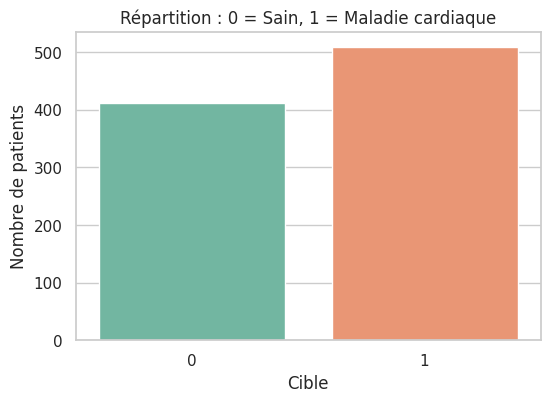


Proportion :
target
1    0.553
0    0.447
Name: proportion, dtype: float64


In [6]:
# num : 0 = pas de maladie ; 1-4 = présence de maladie
print(df["num"].value_counts().sort_index())

# Création de la cible binaire
df["target"] = (df["num"] > 0).astype(int)

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df, palette="Set2")
plt.title("Répartition : 0 = Sain, 1 = Maladie cardiaque")
plt.xlabel("Cible")
plt.ylabel("Nombre de patients")
plt.show()

print("\nProportion :")
print(df["target"].value_counts(normalize=True).round(3))

### 3.2 Valeurs manquantes

Valeurs manquantes par colonne :
ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
chol         30
restecg       2
dtype: int64


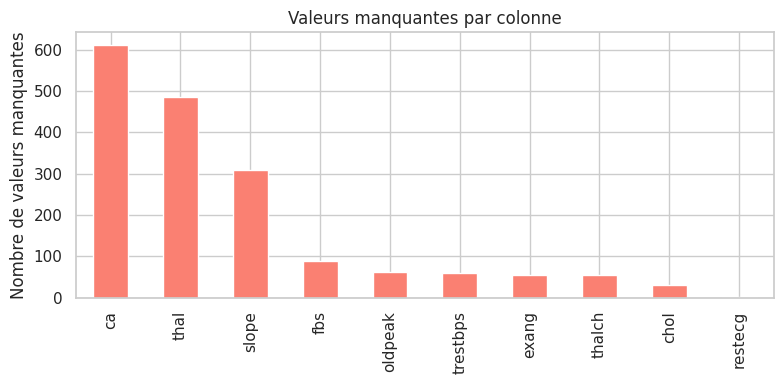

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Valeurs manquantes par colonne :")
print(missing)

plt.figure(figsize=(8,4))
missing.plot(kind="bar", color="salmon")
plt.title("Valeurs manquantes par colonne")
plt.ylabel("Nombre de valeurs manquantes")
plt.tight_layout()
plt.show()

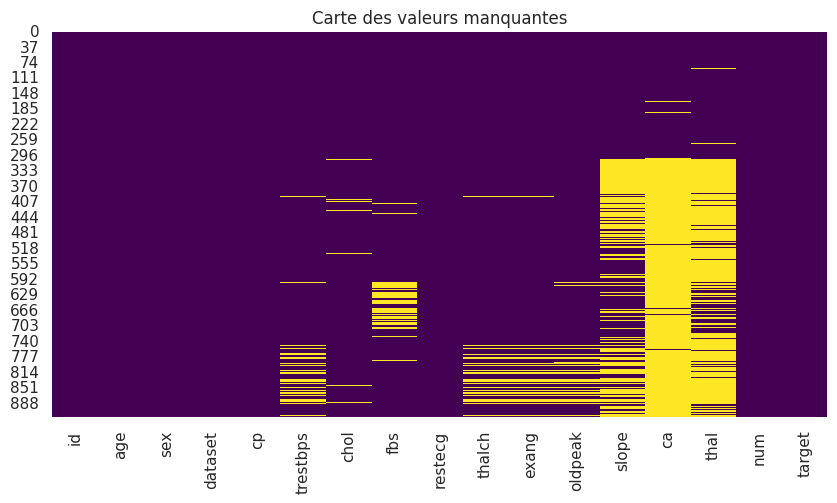

In [8]:
# Carte de chaleur des valeurs manquantes
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Carte des valeurs manquantes")
plt.show()

### 3.3 Distribution des variables numériques

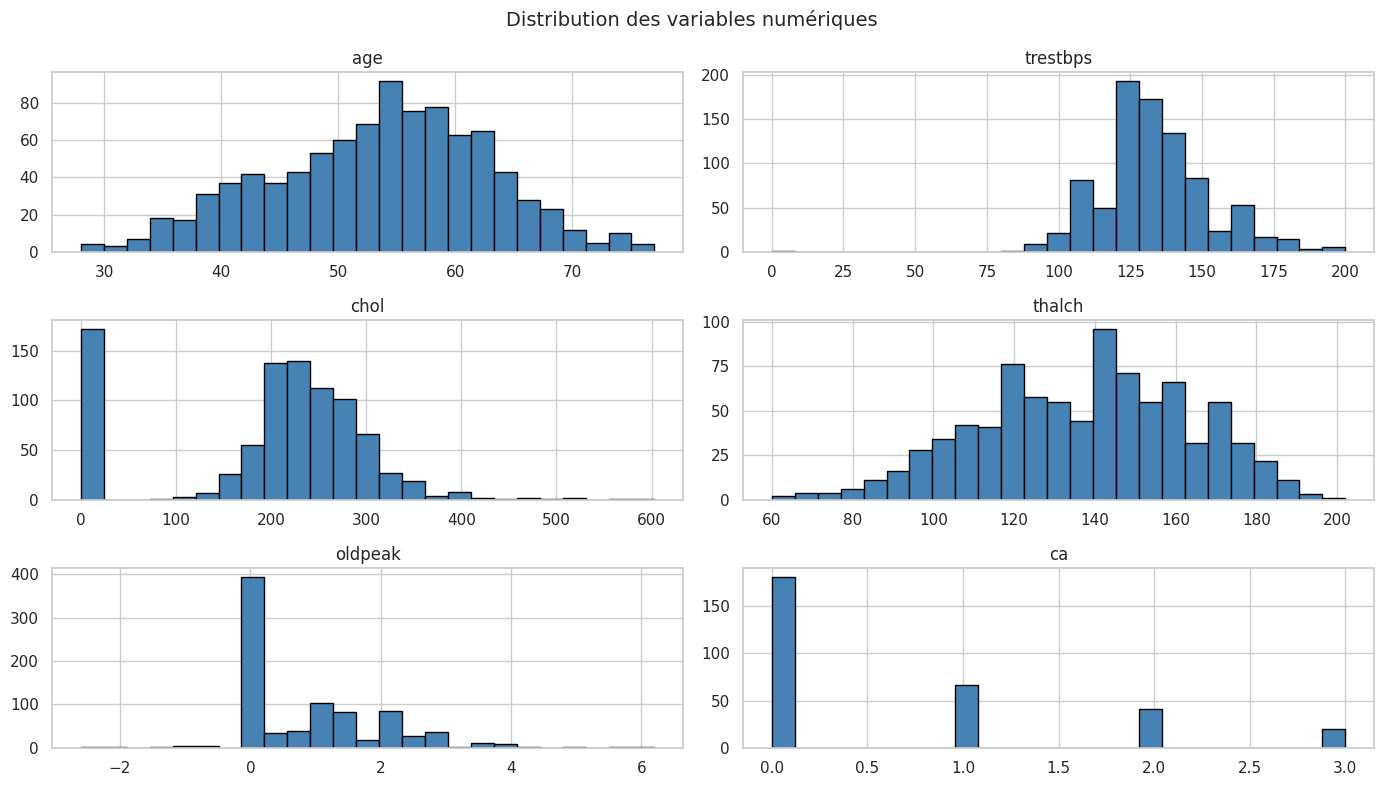

In [9]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

df[num_cols].hist(bins=25, figsize=(14,8), color="steelblue", edgecolor="black")
plt.suptitle("Distribution des variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_574/2874705645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette="Set3", ax=ax)
/tmp/ipykernel_574/2874705645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette="Set3", ax=ax)
/tmp/ipykernel_574/2874705645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, palette="Set3", ax=ax)
/tmp/ipykernel_574/2874705645.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

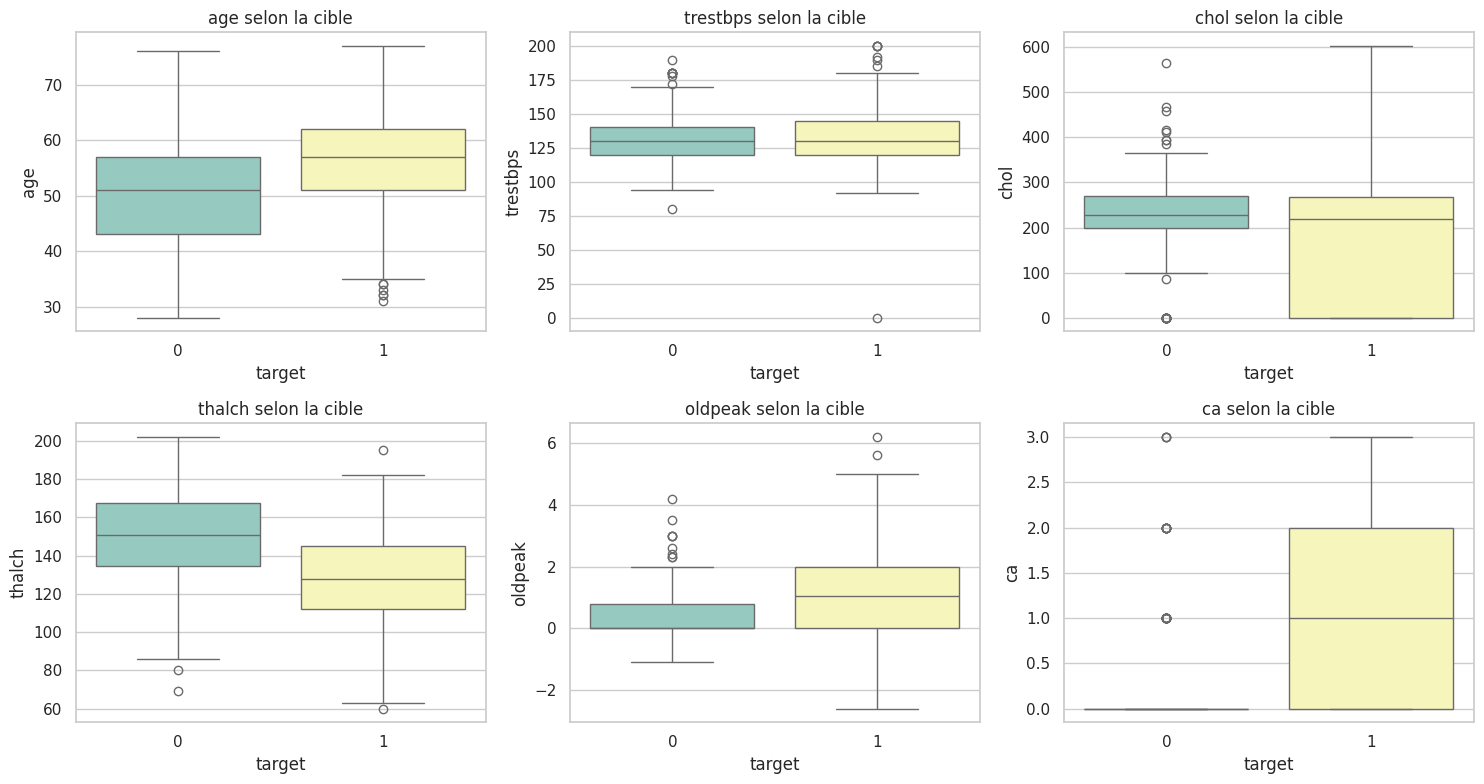

In [10]:
# Variables numériques selon la cible
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x="target", y=col, data=df, palette="Set3", ax=ax)
    ax.set_title(f"{col} selon la cible")
plt.tight_layout()
plt.show()

### 3.4 Variables catégorielles

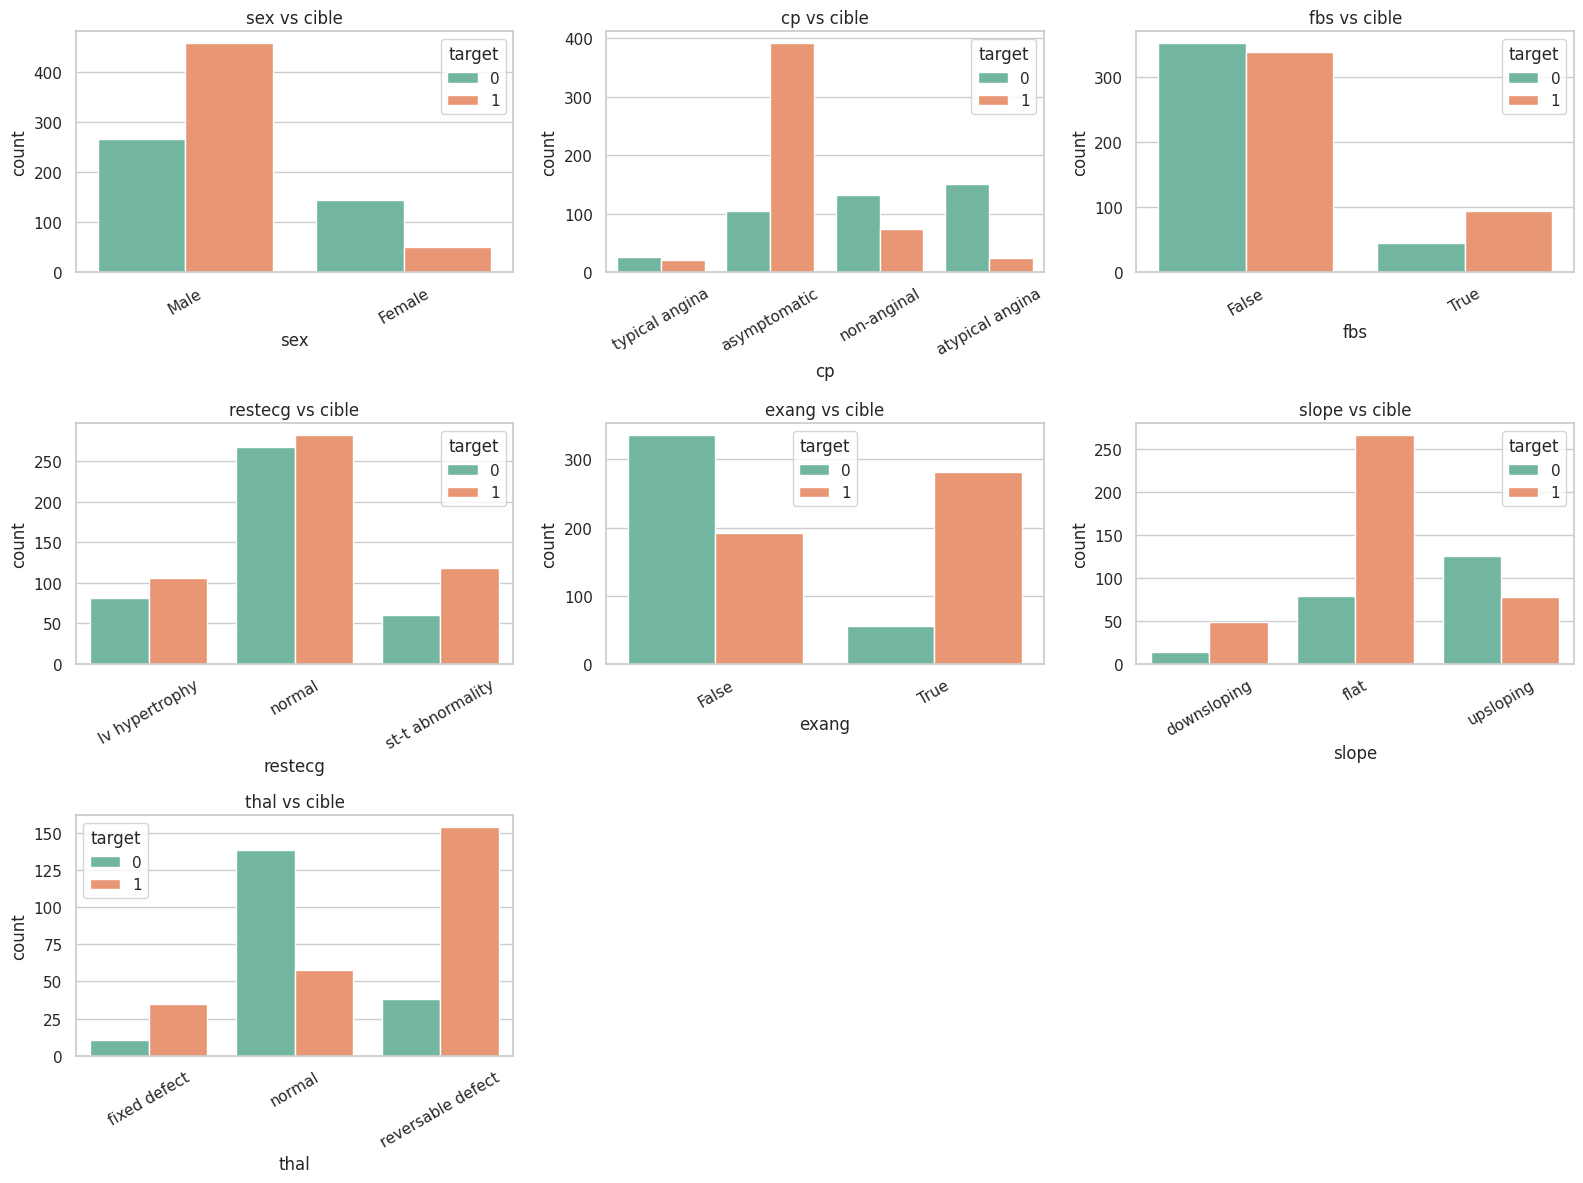

In [11]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, hue="target", data=df, palette="Set2", ax=ax)
    ax.set_title(f"{col} vs cible")
    ax.tick_params(axis="x", rotation=30)
# masquer les axes vides
for ax in axes.flatten()[len(cat_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

### 3.5 Matrice de corrélation (variables numériques)

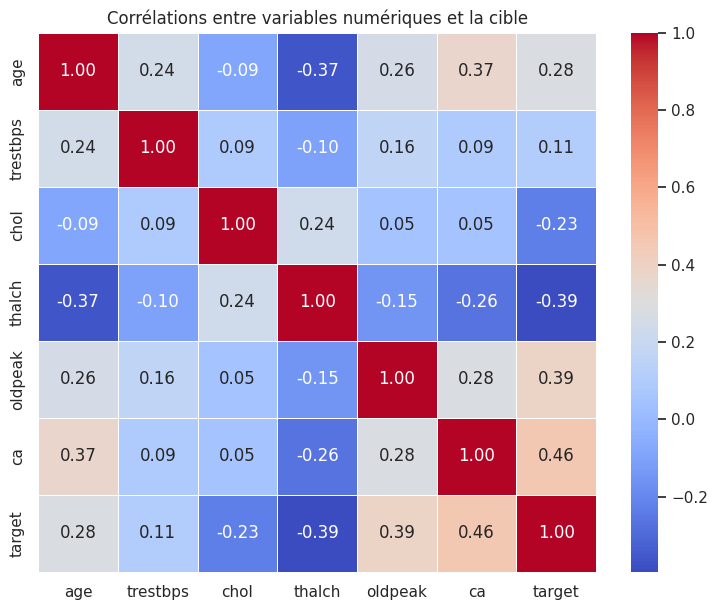

In [12]:
plt.figure(figsize=(9,7))
corr = df[num_cols + ["age", "target"]].drop_duplicates().corr()
corr = df[num_cols + ["target"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Corrélations entre variables numériques et la cible")
plt.show()

## 4. Prétraitement des données

Étapes :
- Suppression des colonnes non pertinentes (`id`, `dataset`, `num`).
- Séparation des variables numériques et catégorielles.
- **Valeurs manquantes** : imputation par la médiane (numériques) et par la valeur la plus fréquente (catégorielles).
- **Encodage** : One-Hot Encoding pour les variables catégorielles.
- **Mise à l'échelle** : StandardScaler pour les variables numériques.

Tout est regroupé dans un `ColumnTransformer` + `Pipeline` pour éviter toute fuite de données (les statistiques d'imputation/mise à l'échelle sont apprises uniquement sur l'ensemble d'entraînement).

In [13]:
# Variables explicatives et cible
X = df.drop(columns=["id", "dataset", "num", "target"])
y = df["target"]

numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

print("Variables numériques :", numeric_features)
print("Variables catégorielles :", categorical_features)
print("Forme de X :", X.shape)

Variables numériques : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Variables catégorielles : ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Forme de X : (920, 13)


In [14]:
# Pipeline pour les variables numériques : imputation médiane + standardisation
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline pour les variables catégorielles : imputation mode + one-hot
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 5. Séparation entraînement / test

80 % pour l'entraînement, 20 % pour le test. On utilise `stratify=y` pour conserver la même proportion de classes dans les deux ensembles.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Entraînement :", X_train.shape, "| Test :", X_test.shape)
print("Répartition cible (train) :\n", y_train.value_counts(normalize=True).round(3))

Entraînement : (736, 13) | Test : (184, 13)
Répartition cible (train) :
 target
1    0.553
0    0.447
Name: proportion, dtype: float64


## 6. Entraînement du modèle de régression logistique

In [16]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)
print("✅ Modèle entraîné avec succès.")

✅ Modèle entraîné avec succès.


## 7. Évaluation du modèle

In [17]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("===== Performances sur l'ensemble de test =====")
print(f"Exactitude (Accuracy) : {accuracy:.3f}")
print(f"Précision (Precision) : {precision:.3f}")
print(f"Rappel (Recall)       : {recall:.3f}")
print(f"Score F1              : {f1:.3f}")

===== Performances sur l'ensemble de test =====
Exactitude (Accuracy) : 0.842
Précision (Precision) : 0.841
Rappel (Recall)       : 0.882
Score F1              : 0.861


### 7.1 Rapport de classification

In [18]:
print(classification_report(y_test, y_pred,
      target_names=["Sain (0)", "Maladie (1)"]))

              precision    recall  f1-score   support

    Sain (0)       0.84      0.79      0.82        82
 Maladie (1)       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



### 7.2 Matrice de confusion

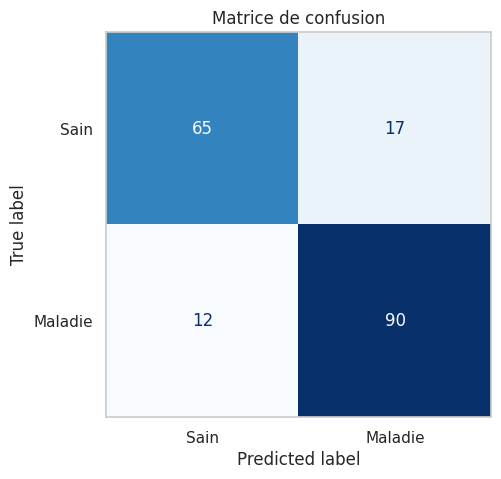

Vrais négatifs : 65  |  Faux positifs : 17
Faux négatifs  : 12  |  Vrais positifs : 90


In [19]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
        display_labels=["Sain", "Maladie"])
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Matrice de confusion")
plt.grid(False)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais négatifs : {tn}  |  Faux positifs : {fp}")
print(f"Faux négatifs  : {fn}  |  Vrais positifs : {tp}")

### 7.3 Courbe ROC et AUC

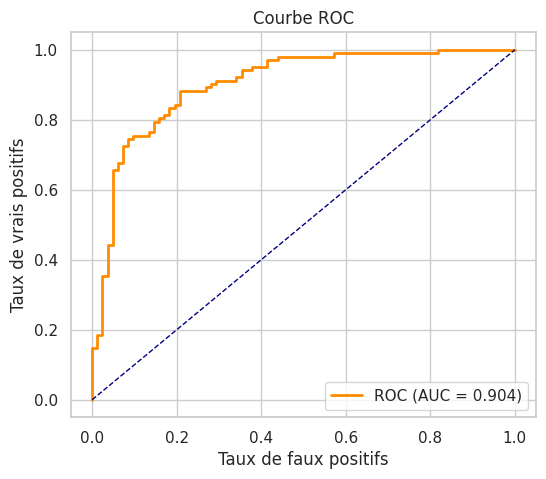

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], color="navy", lw=1, linestyle="--")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC")
plt.legend(loc="lower right")
plt.show()

### 7.4 Importance des variables (coefficients)

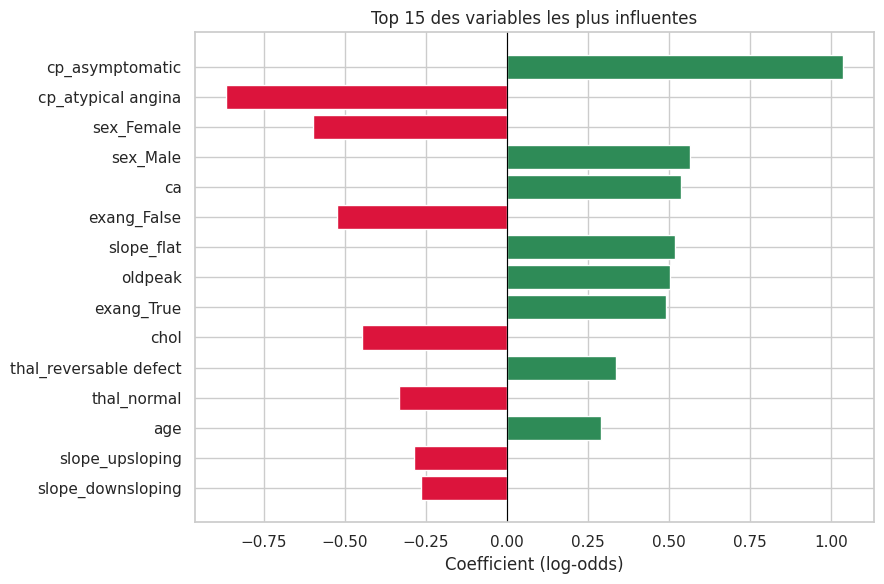

In [21]:
# Récupération des noms de colonnes après one-hot encoding
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

coefs = model.named_steps["classifier"].coef_[0]
coef_df = pd.DataFrame({"variable": feature_names, "coefficient": coefs})
coef_df["abs"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs", ascending=False).head(15)

plt.figure(figsize=(9,6))
colors = ["crimson" if c < 0 else "seagreen" for c in coef_df["coefficient"]]
plt.barh(coef_df["variable"], coef_df["coefficient"], color=colors)
plt.gca().invert_yaxis()
plt.title("Top 15 des variables les plus influentes")
plt.xlabel("Coefficient (log-odds)")
plt.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

## 8. Conclusion

- Le modèle de **régression logistique** prédit la présence d'une maladie cardiaque à partir des attributs médicaux avec de bonnes performances (voir exactitude, précision, rappel et F1 ci-dessus).
- Le **prétraitement** via un `Pipeline` a permis de gérer proprement les valeurs manquantes, l'encodage des variables catégorielles et la mise à l'échelle, sans fuite de données.
- La **matrice de confusion** et la **courbe ROC** montrent la capacité du modèle à distinguer les patients sains des patients malades.
- L'analyse des **coefficients** met en évidence les variables les plus déterminantes (type de douleur thoracique, angine à l'effort, dépression ST `oldpeak`, nombre de vaisseaux `ca`, etc.).

### Pistes d'amélioration
- Tester d'autres modèles (Random Forest, Gradient Boosting) et comparer.
- Optimiser les hyperparamètres avec `GridSearchCV`.
- Ajuster le seuil de décision selon l'importance clinique du rappel (minimiser les faux négatifs).